In [74]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("../acoustooptic_lab/")
from analysis import System as syst
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return array[idx]
def find_idx(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

In [75]:
bundle = syst("bundle", ["data/20250929/power_scan_108kHz_10V_" + str(x) + "mW/iter_" + str(y) + ".tdms" for x in [1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 105, 110, 120, 125] for y in range(0, 20)], set_data = True, channel = "X")
noise = syst("bundle", ["data/20250929/power_scan_108kHz_10V_" + str(x) + "mW_noise/iter_" + str(y) + ".tdms" for x in [1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 105, 110, 120, 125] for y in range(0, 20)], set_data = True, channel = "X")

In [76]:
snrs = np.array([])
powers = np.array([1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 105, 110, 120, 125])
s = np.array([])
n = np.array([])
for i in range(len(bundle.get_data())):
    if i % 20 == 0:
        s = np.array([])
        n = np.array([])
    bundle.set_data(ind = i)
    noise.set_data(ind = i)
    
    d = noise.get_data()[i]
    if len(d.collection[0].t) != 131071:
        d.apply("time_gate", tmin = 0, tmax = 0.065535, inplace = True)
    d.apply("detrend", mode = "linear", inplace = True)
    n_f, n_p = d.average("PSD")
    n = np.append(n, np.sum(n_p[find_idx(n_f, find_nearest(n_f, 108e3)) - 5:find_idx(n_f, find_nearest(n_f, 108e3)) + 5]))
    
    d = bundle.get_data()[i]
    if len(d.collection[0].t) != 131071:
        d.apply("time_gate", tmin = 0, tmax = 0.065535, inplace = True)
    d.apply("detrend", mode = "linear", inplace = True)
    sf, sp = d.average("PSD")
    s = np.append(s, np.sum(sp[find_idx(sf, find_nearest(sf, 108e3)) - 5:find_idx(sf, find_nearest(sf, 108e3)) + 5]))
    
    if i % 19 == 0 and i != 0:
        snrs = np.append(snrs, np.mean(s) / np.mean(n))

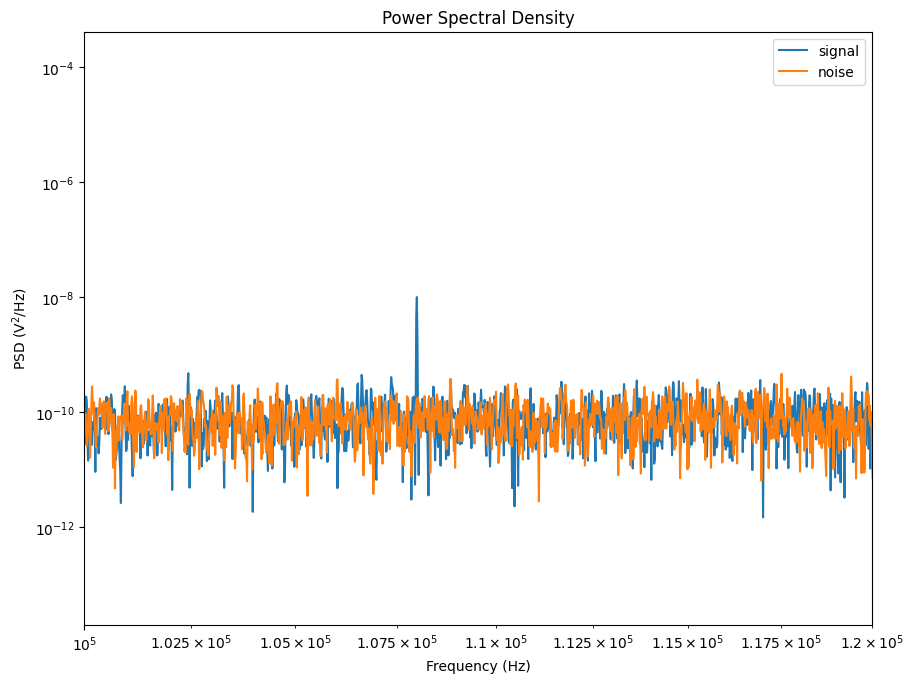

In [98]:
plt.loglog(sf, sp, label = "signal")
plt.loglog(n_f, n_p, label = "noise")
plt.locator_params(axis = "x", numticks = 1)
plt.xlim(1e5, 1.2e5)
plt.title("Power Spectral Density")
plt.xlabel("Frequency (Hz)")
plt.ylabel(r"PSD ($\text{V}^2 / \text{Hz}$)")
plt.tight_layout()
plt.legend()
fig = plt.gcf()
fig.set_size_inches(30 / 3, 15 / 2)
fig.savefig("psd.png")

In [65]:
snrs = 20 * np.log10(snrs)

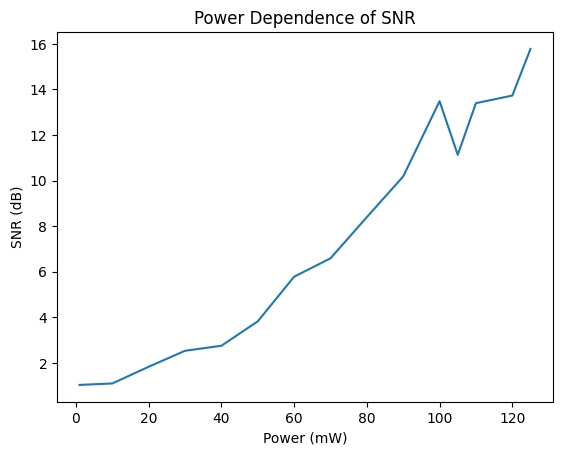

In [100]:
plt.plot(powers, snrs)
plt.xlabel("Power (mW)")
plt.ylabel("SNR (dB)")
plt.title("Power Dependence of SNR")
fig = plt.gcf()
fig.savefig("snr.png")